# Retail Sales Analysis – Exploratory Data Analysis
**Dataset:** `data/processed/sales_cleaned.csv`  
**500 transactions · 16 columns · Full year 2024**

---
### Contents
1. Setup & Data Load  
2. KPI Summary (Total Net Sales · Total Quantity · Transactions · Avg Order Value)  
3. Monthly Net Sales  
4. Sales by City  
5. Sales by Product Category  
6. Sales by Product  
7. Sales by Gender  
8. Sales by Payment Method  
9. Top 10 Products by Net Sales  
10. Top 10 Customers by Net Sales  
11. Discount Percentage vs Net Sales  

---
## 1. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'figure.facecolor': 'white',
})
BLUE   = '#3b82d4'
ORANGE = '#f59e0b'
GREEN  = '#10b981'
RED    = '#ef4444'
PURPLE = '#7c5cd8'
PALETTE = [BLUE, ORANGE, GREEN, RED, PURPLE,
           '#f97316','#06b6d4','#84cc16','#ec4899','#64748b']

# ── Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/sales_cleaned.csv')
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['Month']  = df['Transaction_Date'].dt.to_period('M')
df['Month_Label'] = df['Transaction_Date'].dt.strftime('%b %Y')

print(f'Shape : {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape : (500, 18)
Columns: ['Transaction_ID', 'Transaction_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'City', 'Product_Category', 'Product', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Payment_Method', 'Gross_Sales', 'Discount_Amount', 'Net_Sales', 'Month', 'Month_Label']


,Transaction_ID,Transaction_Date,Customer_ID,Customer_Name,Gender,Age,City,Product_Category,Product,Quantity,Unit_Price,Discount_Percentage,Payment_Method,Gross_Sales,Discount_Amount,Net_Sales,Month,Month_Label
0,TXN12080,2024-09-01,CUST1029,Krishna Patel,Male,30,Ahmedabad,Sports,Cricket Bat,8,1856.85,7.72,Cash,14854.80,1146.79,13708.01,2024-09,Sep 2024
1,TXN12283,2024-04-27,CUST1077,Krishna Sharma,Male,57,Kolkata,Home & Kitchen,Pressure Cooker,1,1998.76,24.49,Cash,1998.76,489.50,1509.26,2024-04,Apr 2024
2,TXN19794,2024-01-17,CUST1143,Deepak Tiwari,Male,42,Delhi,Electronics,Laptop,6,86053.26,0.12,Cash,516319.56,619.58,515699.98,2024-01,Jan 2024


---
## 2. KPI Summary

In [2]:
total_net_sales   = df['Net_Sales'].sum()
total_quantity    = df['Quantity'].sum()
num_transactions  = len(df)
avg_order_value   = df['Net_Sales'].mean()

print('=' * 45)
print('  KEY PERFORMANCE INDICATORS')
print('=' * 45)
print(f'  Total Net Sales      : ₹{total_net_sales:>15,.2f}')
print(f'  Total Quantity Sold  : {total_quantity:>15,}')
print(f'  Number of Transactions: {num_transactions:>14,}')
print(f'  Average Order Value  : ₹{avg_order_value:>15,.2f}')
print('=' * 45)

  KEY PERFORMANCE INDICATORS
  Total Net Sales      : ₹  13,171,997.03
  Total Quantity Sold  :           2,746
  Number of Transactions:            500
  Average Order Value  : ₹      26,343.99


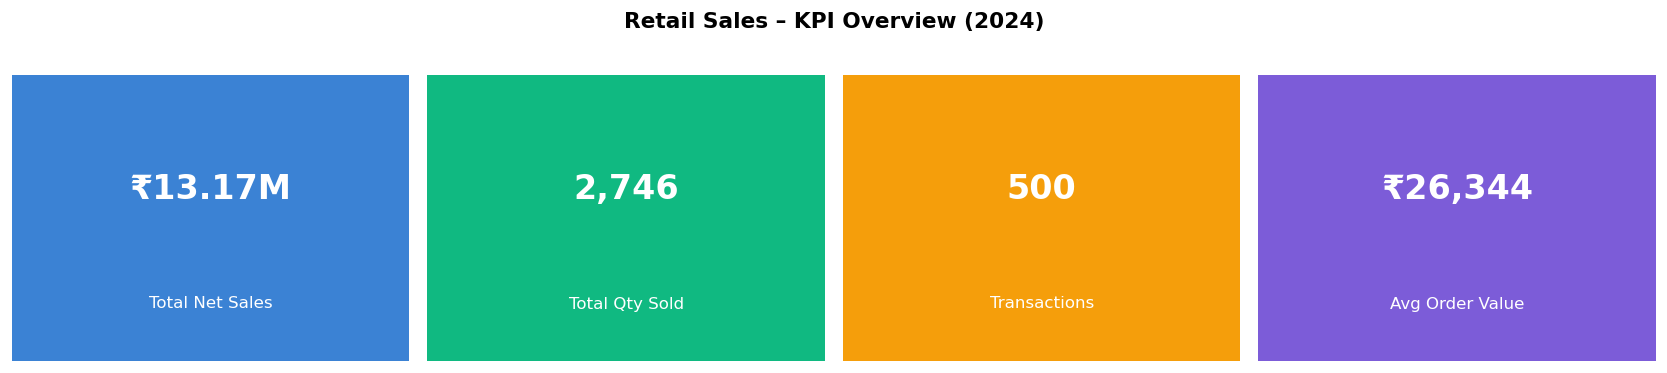

In [3]:
# ── KPI Tile Chart ────────────────────────────────────────────────────────
kpi_labels = ['Total Net Sales', 'Total Qty Sold',
              'Transactions', 'Avg Order Value']
kpi_values = [f'₹{total_net_sales/1e6:.2f}M',
              f'{total_quantity:,}',
              f'{num_transactions:,}',
              f'₹{avg_order_value:,.0f}']
kpi_colors = [BLUE, GREEN, ORANGE, PURPLE]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, label, value, color in zip(axes, kpi_labels, kpi_values, kpi_colors):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value,  ha='center', va='center',
            fontsize=20, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center',
            fontsize=10, color='white', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

fig.suptitle('Retail Sales – KPI Overview (2024)', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/01_kpi_tiles.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
The dataset covers **500 transactions** across 2024, generating **₹13.17 M** in net revenue from **2,746 units** sold.  
The average order value is **₹26,344**, which is heavily influenced by high-ticket electronics purchases.

---
## 3. Monthly Net Sales

In [4]:
monthly = (
    df.groupby('Month')['Net_Sales']
      .sum()
      .reset_index()
      .sort_values('Month')
)
monthly['Month_Str'] = monthly['Month'].astype(str)
monthly['Month_Short'] = pd.to_datetime(monthly['Month_Str']).dt.strftime('%b')
monthly['Net_Sales_Lakh'] = (monthly['Net_Sales'] / 1e5).round(2)

print(monthly[['Month_Str', 'Net_Sales']].rename(
    columns={'Month_Str': 'Month', 'Net_Sales': 'Net Sales (₹)'}).to_string(index=False))

  Month  Net Sales (₹)
2024-01     1887219.01
2024-02     1396418.59
2024-03      650928.71
2024-04     1455930.31
2024-05     1322479.88
2024-06     1098913.84
2024-07      873460.07
2024-08      511922.92
2024-09      674675.49
2024-10      859817.23
2024-11      635409.55
2024-12     1804821.43


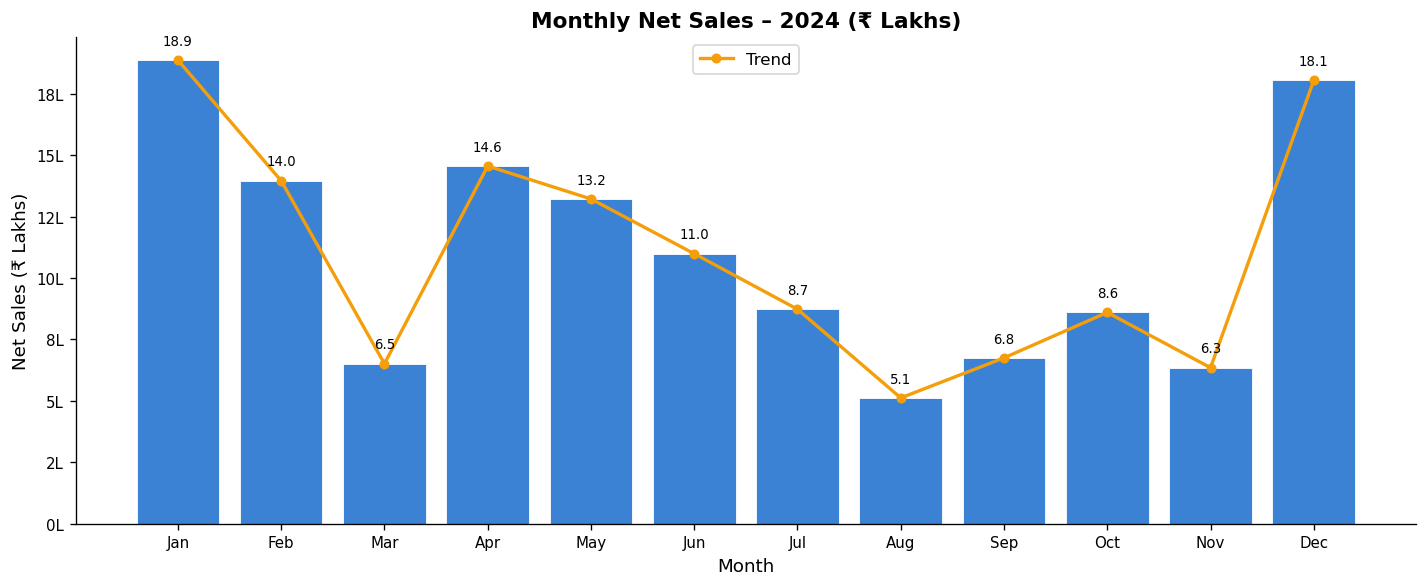

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(monthly['Month_Short'], monthly['Net_Sales_Lakh'],
              color=BLUE, edgecolor='white', linewidth=0.5)
ax.plot(monthly['Month_Short'], monthly['Net_Sales_Lakh'],
        color=ORANGE, marker='o', linewidth=2, markersize=5, label='Trend')

for bar, val in zip(bars, monthly['Net_Sales_Lakh']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Monthly Net Sales – 2024 (₹ Lakhs)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Net Sales (₹ Lakhs)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}L'))
plt.tight_layout()
plt.savefig('../reports/02_monthly_sales.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
January (₹18.9 L) and December (₹18.0 L) record the highest net sales — consistent with year-start and year-end shopping peaks.  
April (₹14.6 L) and February (₹14.0 L) are also strong months.  
August (₹5.1 L) is the lowest month, suggesting a mid-year sales dip.

---
## 4. Sales by City

In [6]:
city_sales = (
    df.groupby('City')['Net_Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)
city_sales['Net_Sales_Lakh'] = (city_sales['Net_Sales'] / 1e5).round(2)
print(city_sales[['City', 'Net_Sales']].rename(columns={'Net_Sales': 'Net Sales (₹)'}).to_string(index=False))

     City  Net Sales (₹)
    Delhi     2001958.72
  Kolkata     1922361.65
  Chennai     1860444.40
Hyderabad     1742885.93
   Mumbai     1560442.88
   Jaipur     1154688.80
     Pune     1050956.53
    Surat      965380.29
Bangalore      514685.71
Ahmedabad      398192.12


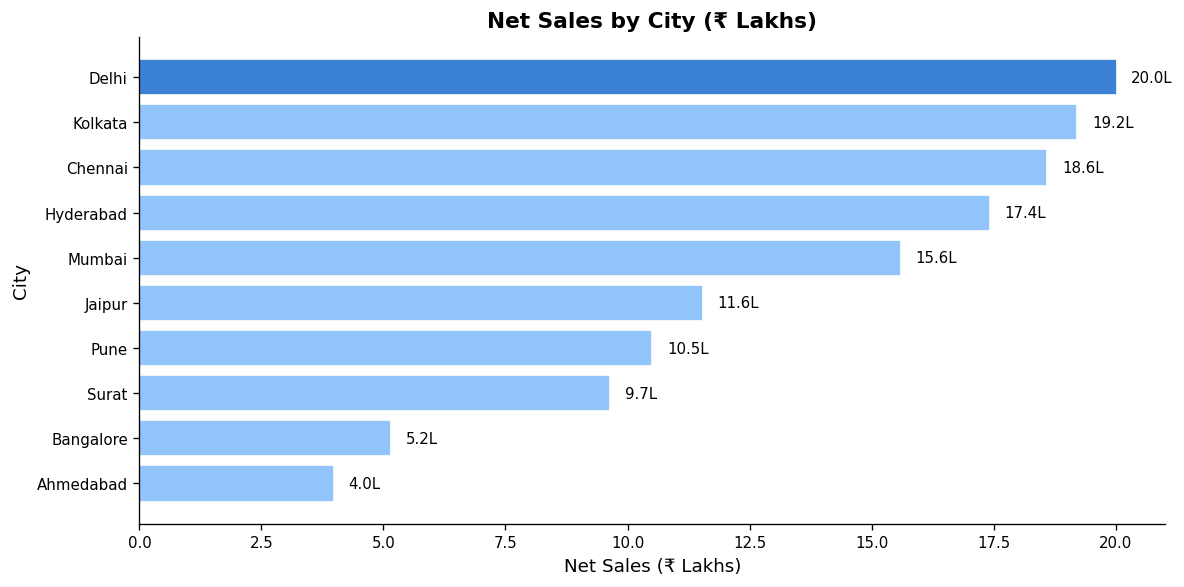

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = [BLUE if i == 0 else '#93c5fd' for i in range(len(city_sales))]
bars = ax.barh(city_sales['City'][::-1], city_sales['Net_Sales_Lakh'][::-1],
               color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, city_sales['Net_Sales_Lakh'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}L', va='center', fontsize=9)

ax.set_title('Net Sales by City (₹ Lakhs)', fontweight='bold')
ax.set_xlabel('Net Sales (₹ Lakhs)')
ax.set_ylabel('City')
plt.tight_layout()
plt.savefig('../reports/03_sales_by_city.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
**Delhi** leads with ₹20.0 L in net sales, followed closely by **Kolkata** (₹19.2 L) and **Chennai** (₹18.6 L).  
**Bangalore** (₹5.1 L) and **Ahmedabad** (₹4.0 L) are the lowest-contributing cities, likely due to fewer high-value transactions.

---
## 5. Sales by Product Category

In [8]:
cat_sales = (
    df.groupby('Product_Category')['Net_Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)
cat_sales['Pct'] = (cat_sales['Net_Sales'] / cat_sales['Net_Sales'].sum() * 100).round(2)
print(cat_sales[['Product_Category', 'Net_Sales', 'Pct']].rename(
    columns={'Product_Category': 'Category', 'Net_Sales': 'Net Sales (₹)', 'Pct': 'Share %'}
).to_string(index=False))

      Category  Net Sales (₹)  Share %
   Electronics    10995489.59    83.48
        Sports      526621.48     4.00
      Clothing      432932.09     3.29
Home & Kitchen      432726.20     3.29
          Toys      324655.51     2.46
        Beauty      238725.17     1.81
     Groceries      116883.64     0.89
         Books      103963.35     0.79


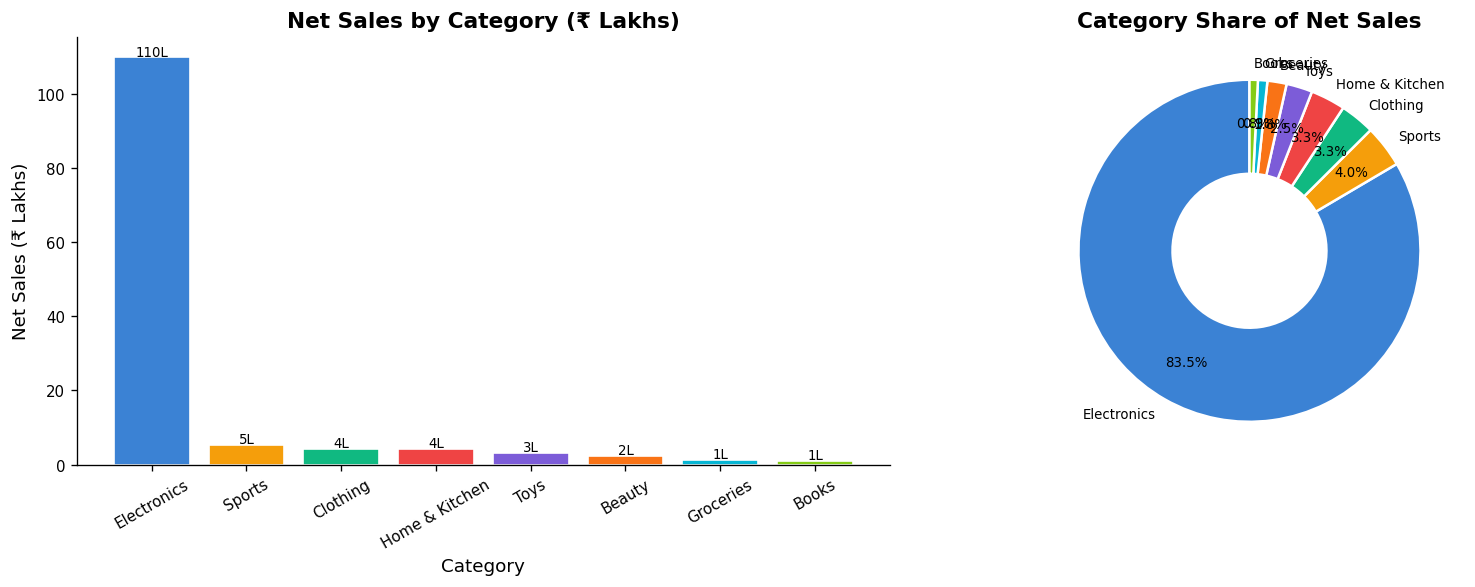

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar
cat_sales_lakh = cat_sales['Net_Sales'] / 1e5
ax1.bar(cat_sales['Product_Category'], cat_sales_lakh,
        color=PALETTE[:len(cat_sales)], edgecolor='white')
ax1.set_title('Net Sales by Category (₹ Lakhs)', fontweight='bold')
ax1.set_xlabel('Category')
ax1.set_ylabel('Net Sales (₹ Lakhs)')
ax1.tick_params(axis='x', rotation=30)
for i, (bar, val) in enumerate(zip(ax1.patches, cat_sales_lakh)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}L', ha='center', fontsize=8)

# Pie
wedge_props = dict(width=0.55, edgecolor='white', linewidth=1.5)
ax2.pie(cat_sales['Net_Sales'], labels=cat_sales['Product_Category'],
        autopct='%1.1f%%', colors=PALETTE[:len(cat_sales)],
        wedgeprops=wedge_props, startangle=90, pctdistance=0.75,
        textprops={'fontsize': 8})
ax2.set_title('Category Share of Net Sales', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/04_sales_by_category.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
**Electronics dominates** with ₹109.95 L (83.5% of total net sales) — driven primarily by high unit prices (laptops, smartphones, tablets).  
All other 7 categories combined contribute only 16.5%, with Books (₹1.0 L) and Groceries (₹1.2 L) at the bottom.

---
## 6. Sales by Product

In [10]:
prod_sales = (
    df.groupby('Product')['Net_Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)
prod_sales['Net_Sales_Lakh'] = (prod_sales['Net_Sales'] / 1e5).round(2)
print('All products by Net Sales:')
print(prod_sales[['Product', 'Net_Sales']].to_string(index=False))

All products by Net Sales:
        Product  Net_Sales
         Laptop 5690034.56
     Smartphone 2465053.88
         Tablet 1943912.51
     Smartwatch  623459.99
      Earphones  273028.65
    Cricket Bat  224629.67
  Mixer Grinder  212522.31
      Dumbbells  155424.04
     Remote Car  133612.71
         Jacket  130931.79
          Saree  127808.19
Pressure Cooker  112932.70
        Perfume  109832.97
       Football   73364.81
          Jeans   70372.54
  Women's Kurti   67548.75
     Puzzle Set   60600.14
     Board Game   56157.54
       Curtains   49090.65
   Bedsheet Set   48597.20
           Doll   48115.20
       Lipstick   42104.55
     Face Cream   41082.58
  Badminton Set   37961.35
       Textbook   37322.08
  Men's T-Shirt   36270.82
       Yoga Mat   35241.61
  Flour (10 kg)   33329.51
    Cooking Oil   32844.96
    Rice (5 kg)   29187.87
 Self-Help Book   27258.63
  Action Figure   26169.92
        Shampoo   24128.70
      Sunscreen   21576.37
  Children Book   18035.48
 

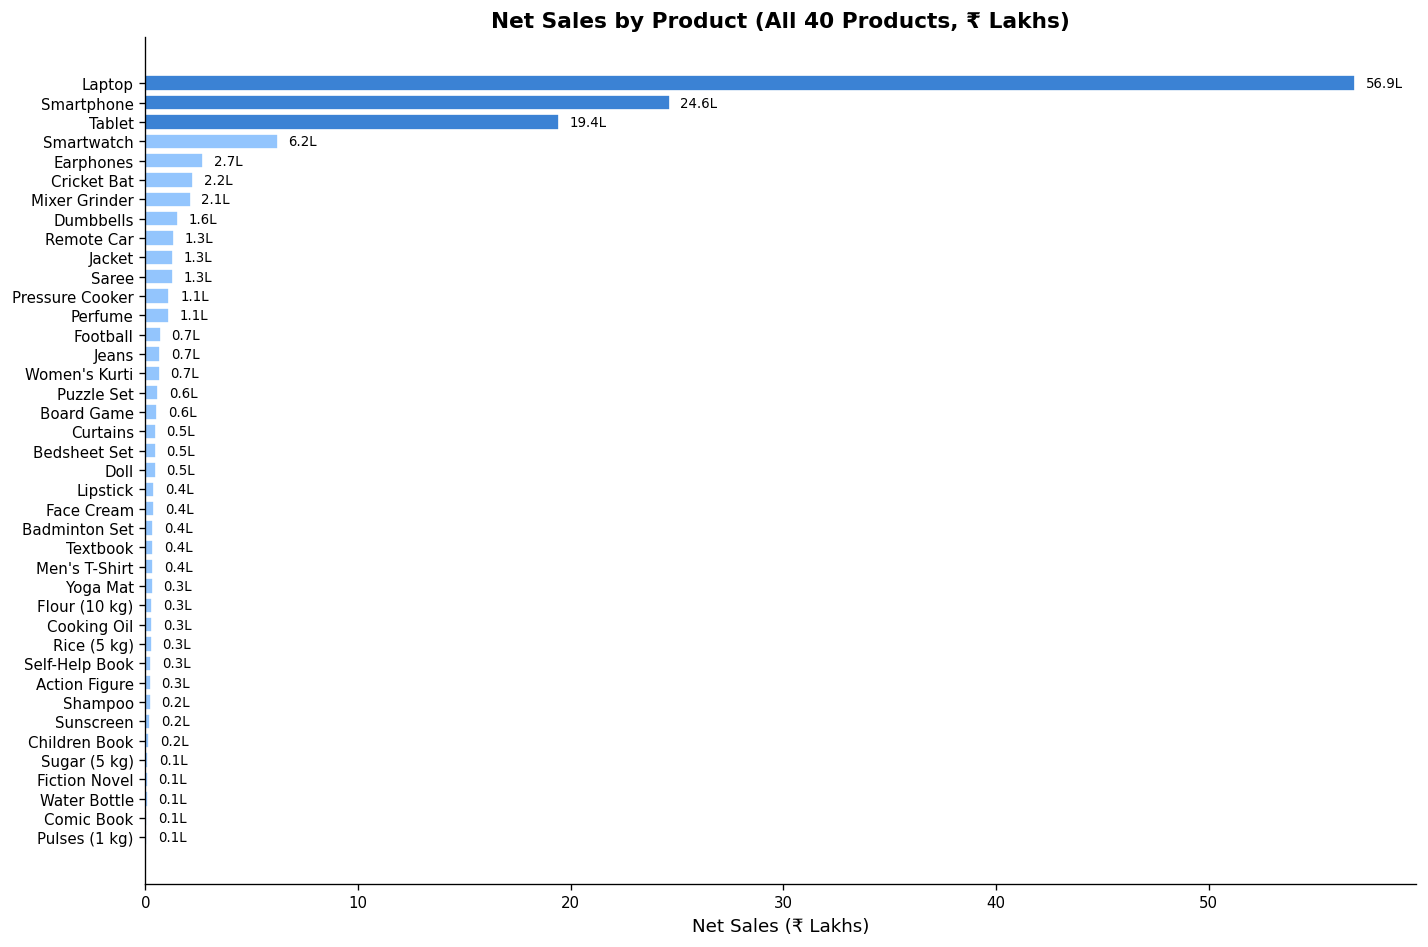

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = [BLUE if i < 3 else '#93c5fd' for i in range(len(prod_sales))]
ax.barh(prod_sales['Product'][::-1], prod_sales['Net_Sales_Lakh'][::-1],
        color=colors[::-1], edgecolor='white')

for patch, val in zip(ax.patches, prod_sales['Net_Sales_Lakh'][::-1]):
    ax.text(patch.get_width() + 0.5, patch.get_y() + patch.get_height()/2,
            f'{val:.1f}L', va='center', fontsize=8)

ax.set_title('Net Sales by Product (All 40 Products, ₹ Lakhs)', fontweight='bold')
ax.set_xlabel('Net Sales (₹ Lakhs)')
plt.tight_layout()
plt.savefig('../reports/05_sales_by_product.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
**Laptop** (₹56.9 L) is by far the top-selling product, followed by **Smartphone** (₹24.7 L) and **Tablet** (₹19.4 L).  
The top 3 products are all Electronics, confirming the category dominance observed above.  
Low-value daily products (Comic Books, Children Books, Pulses) sit at the bottom.

---
## 7. Sales by Gender

In [12]:
gender_sales = (
    df.groupby('Gender')
      .agg(Net_Sales=('Net_Sales', 'sum'),
           Transactions=('Transaction_ID', 'count'),
           Avg_Order=('Net_Sales', 'mean'))
      .round(2)
      .reset_index()
)
gender_sales['Share_Pct'] = (gender_sales['Net_Sales'] / gender_sales['Net_Sales'].sum() * 100).round(2)
print(gender_sales.to_string(index=False))

Gender  Net_Sales  Transactions  Avg_Order  Share_Pct
Female 6639631.27           251   26452.71      50.41
  Male 6532365.76           249   26234.40      49.59


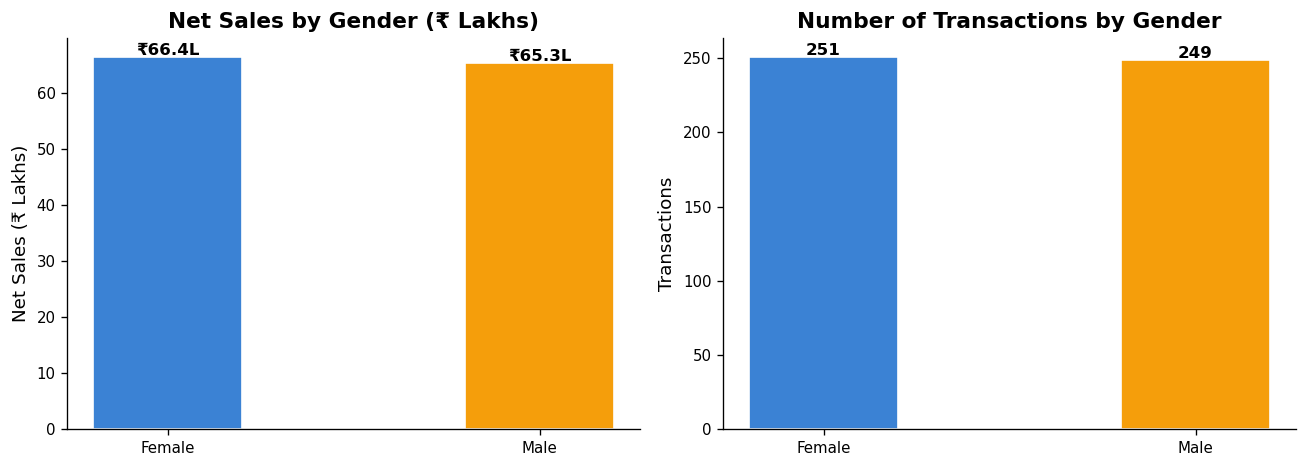

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Net Sales bar
gen_colors = [BLUE, ORANGE]
bars = ax1.bar(gender_sales['Gender'],
               gender_sales['Net_Sales'] / 1e5,
               color=gen_colors, edgecolor='white', width=0.4)
for bar, val in zip(bars, gender_sales['Net_Sales'] / 1e5):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'₹{val:.1f}L', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Net Sales by Gender (₹ Lakhs)', fontweight='bold')
ax1.set_ylabel('Net Sales (₹ Lakhs)')

# Transaction count
bars2 = ax2.bar(gender_sales['Gender'],
                gender_sales['Transactions'],
                color=gen_colors, edgecolor='white', width=0.4)
for bar, val in zip(bars2, gender_sales['Transactions']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(int(val)), ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Number of Transactions by Gender', fontweight='bold')
ax2.set_ylabel('Transactions')

plt.tight_layout()
plt.savefig('../reports/06_sales_by_gender.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
Sales are nearly split between genders: **Female customers** account for ₹66.4 L (50.4%) and **Male customers** ₹65.3 L (49.6%).  
Female customers made 251 transactions vs Male 249 — effectively an equal split, consistent with the balanced dataset design.

---
## 8. Sales by Payment Method

In [14]:
pay_sales = (
    df.groupby('Payment_Method')
      .agg(Net_Sales=('Net_Sales', 'sum'),
           Transactions=('Transaction_ID', 'count'))
      .sort_values('Net_Sales', ascending=False)
      .reset_index()
)
pay_sales['Share_Pct'] = (pay_sales['Net_Sales'] / pay_sales['Net_Sales'].sum() * 100).round(2)
print(pay_sales.to_string(index=False))

Payment_Method  Net_Sales  Transactions  Share_Pct
        Wallet 3182988.25            81      24.16
   Net Banking 2623690.97            81      19.92
          Cash 2384754.87            83      18.10
           UPI 2108483.31            85      16.01
   Credit Card 1718727.25            87      13.05
    Debit Card 1153352.38            83       8.76


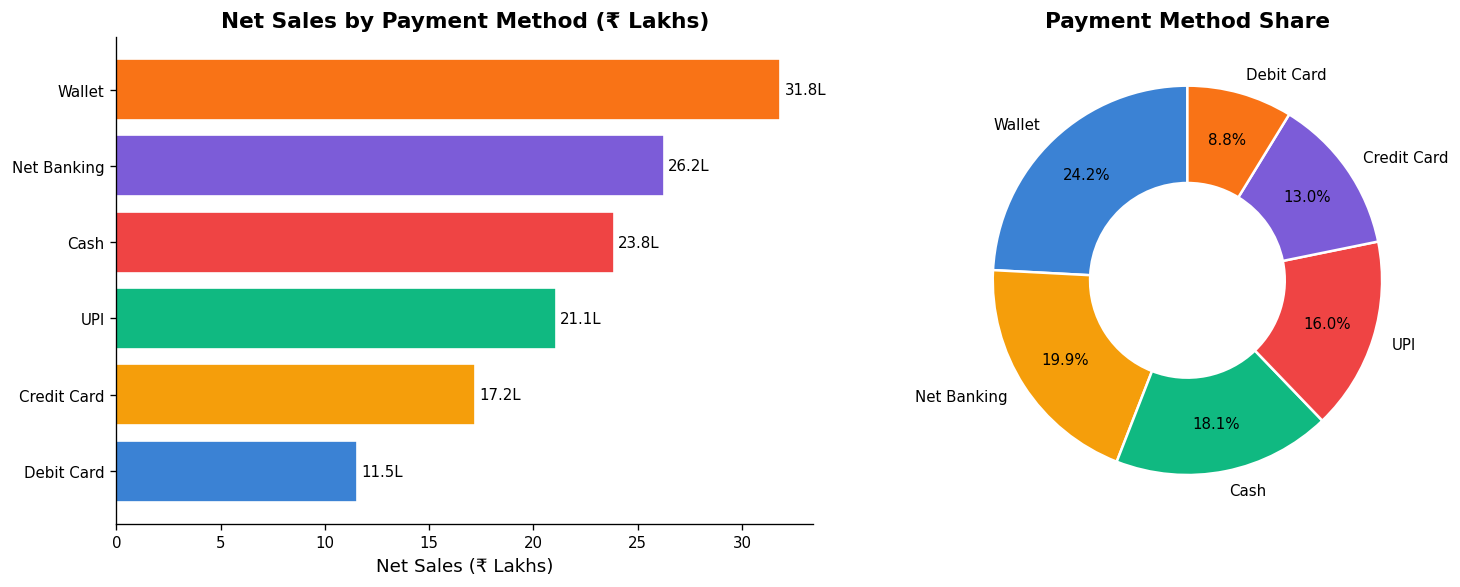

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Horizontal bar
ax1.barh(pay_sales['Payment_Method'][::-1],
         pay_sales['Net_Sales'][::-1] / 1e5,
         color=PALETTE[:len(pay_sales)], edgecolor='white')
for patch, val in zip(ax1.patches, pay_sales['Net_Sales'][::-1] / 1e5):
    ax1.text(patch.get_width() + 0.2, patch.get_y() + patch.get_height()/2,
             f'{val:.1f}L', va='center', fontsize=9)
ax1.set_title('Net Sales by Payment Method (₹ Lakhs)', fontweight='bold')
ax1.set_xlabel('Net Sales (₹ Lakhs)')

# Donut
wedge_props = dict(width=0.5, edgecolor='white', linewidth=1.5)
ax2.pie(pay_sales['Net_Sales'],
        labels=pay_sales['Payment_Method'],
        autopct='%1.1f%%',
        colors=PALETTE[:len(pay_sales)],
        wedgeprops=wedge_props,
        startangle=90,
        pctdistance=0.75,
        textprops={'fontsize': 9})
ax2.set_title('Payment Method Share', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/07_sales_by_payment.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
**Wallet** is the top payment method by net sales (₹31.8 L, 24.2%), followed by **Net Banking** (₹26.2 L, 19.9%) and **Cash** (₹23.8 L, 18.1%).  
**Debit Card** is the least used method (₹11.5 L, 8.8%), indicating customer preference for digital wallets and online banking over physical cards.

---
## 9. Top 10 Products by Net Sales

In [16]:
top10_prod = (
    df.groupby('Product')['Net_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top10_prod['Net_Sales_Lakh'] = (top10_prod['Net_Sales'] / 1e5).round(2)
top10_prod['Rank'] = range(1, 11)
print(top10_prod[['Rank', 'Product', 'Net_Sales']].rename(
    columns={'Net_Sales': 'Net Sales (₹)'}).to_string(index=False))

 Rank       Product  Net Sales (₹)
    1        Laptop     5690034.56
    2    Smartphone     2465053.88
    3        Tablet     1943912.51
    4    Smartwatch      623459.99
    5     Earphones      273028.65
    6   Cricket Bat      224629.67
    7 Mixer Grinder      212522.31
    8     Dumbbells      155424.04
    9    Remote Car      133612.71
   10        Jacket      130931.79


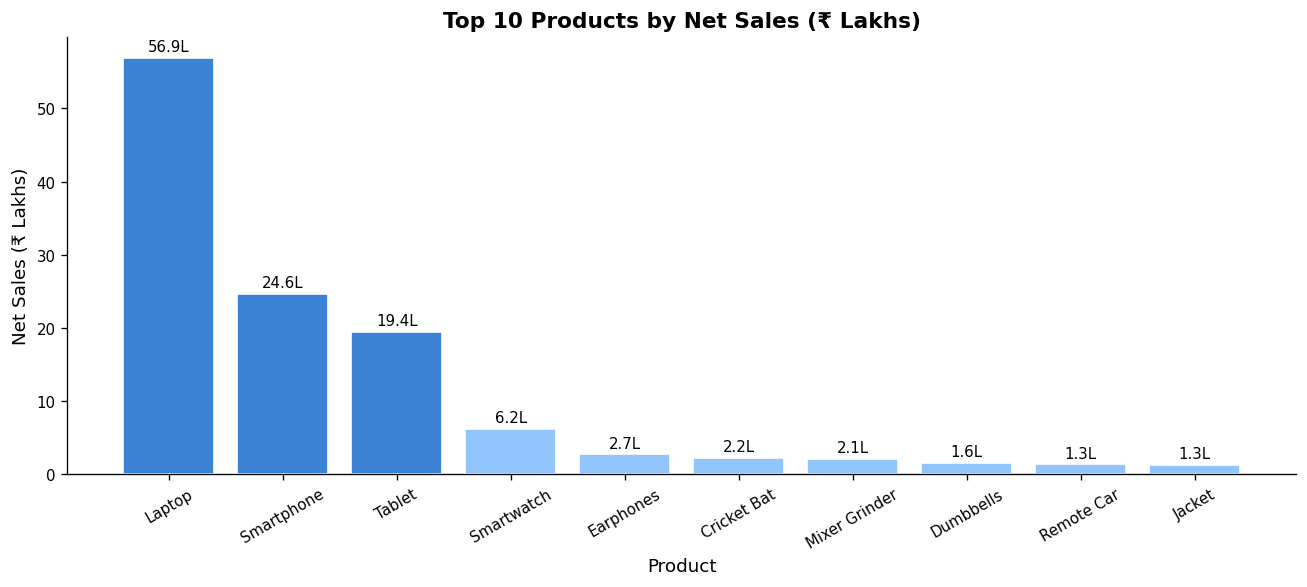

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))

bar_colors = [BLUE if i == 0 else ('#3b82d4' if i < 3 else '#93c5fd')
              for i in range(len(top10_prod))]
bars = ax.bar(top10_prod['Product'], top10_prod['Net_Sales_Lakh'],
              color=bar_colors, edgecolor='white')

for bar, val in zip(bars, top10_prod['Net_Sales_Lakh']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}L', ha='center', va='bottom', fontsize=9)

ax.set_title('Top 10 Products by Net Sales (₹ Lakhs)', fontweight='bold')
ax.set_ylabel('Net Sales (₹ Lakhs)')
ax.set_xlabel('Product')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../reports/08_top10_products.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
**Laptop** (₹56.9 L) outsells the second-ranked **Smartphone** (₹24.7 L) by more than 2×.  
The top 5 products are all Electronics. **Cricket Bat** (₹2.2 L) is the only non-Electronics product in the top 10.

---
## 10. Top 10 Customers by Net Sales

In [18]:
top10_cust = (
    df.groupby('Customer_Name')
      .agg(Net_Sales=('Net_Sales', 'sum'),
           Transactions=('Transaction_ID', 'count'))
      .sort_values('Net_Sales', ascending=False)
      .head(10)
      .reset_index()
)
top10_cust['Net_Sales_Lakh'] = (top10_cust['Net_Sales'] / 1e5).round(2)
top10_cust['Rank'] = range(1, 11)
print(top10_cust[['Rank', 'Customer_Name', 'Net_Sales', 'Transactions']].rename(
    columns={'Net_Sales': 'Net Sales (₹)', 'Customer_Name': 'Customer'}
).to_string(index=False))

 Rank          Customer  Net Sales (₹)  Transactions
    1       Vivaan Shah      700024.74             1
    2      Anjali Mehta      583268.12             1
    3 Anjali Srivastava      540979.79             1
    4     Deepak Tiwari      526979.12             3
    5        Vihaan Rao      487968.01             1
    6       Priya Patel      482984.54             1
    7         Amit Bose      451788.77             1
    8      Pooja Pandey      399096.82             2
    9         Sai Joshi      354898.75             2
   10      Suresh Yadav      352095.48             1


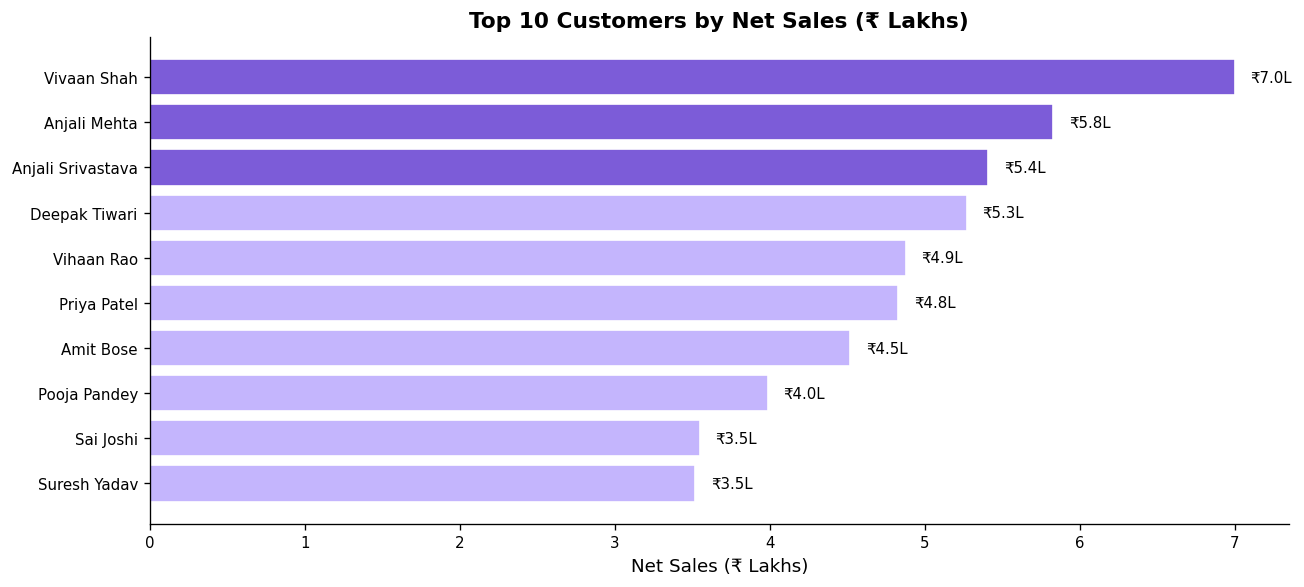

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))

cust_colors = [PURPLE if i == 0 else ('#7c5cd8' if i < 3 else '#c4b5fd')
               for i in range(len(top10_cust))]
bars = ax.barh(top10_cust['Customer_Name'][::-1],
               top10_cust['Net_Sales_Lakh'][::-1],
               color=cust_colors[::-1], edgecolor='white')

for bar, val in zip(bars, top10_cust['Net_Sales_Lakh'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'₹{val:.1f}L', va='center', fontsize=9)

ax.set_title('Top 10 Customers by Net Sales (₹ Lakhs)', fontweight='bold')
ax.set_xlabel('Net Sales (₹ Lakhs)')
plt.tight_layout()
plt.savefig('../reports/09_top10_customers.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
**Vivaan Shah** is the highest-value customer (₹7.0 L), followed by **Anjali Mehta** (₹5.8 L) and **Anjali Srivastava** (₹5.4 L).  
High individual spend is likely due to multiple Electronics purchases at high unit prices.

---
## 11. Discount Percentage vs Net Sales

In [20]:
corr = df['Discount_Percentage'].corr(df['Net_Sales'])
print(f'Pearson correlation (Discount_Percentage vs Net_Sales) : {corr:.4f}')

# Bin discounts into 6 bands and show average Net_Sales per band
df['Discount_Band'] = pd.cut(df['Discount_Percentage'],
                             bins=[0, 5, 10, 15, 20, 25, 30],
                             labels=['0-5%','5-10%','10-15%','15-20%','20-25%','25-30%'],
                             include_lowest=True)

disc_band = (
    df.groupby('Discount_Band', observed=True)['Net_Sales']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'Avg_Net_Sales', 'count': 'Transactions'})
      .reset_index()
)
disc_band['Avg_Net_Sales'] = disc_band['Avg_Net_Sales'].round(2)
print(disc_band.to_string(index=False))

Pearson correlation (Discount_Percentage vs Net_Sales) : -0.0943
Discount_Band  Avg_Net_Sales  Transactions
         0-5%       32825.39            91
        5-10%       24733.93            82
       10-15%       30789.28            84
       15-20%       44803.05            78
       20-25%       17085.26            86
       25-30%        7676.39            79


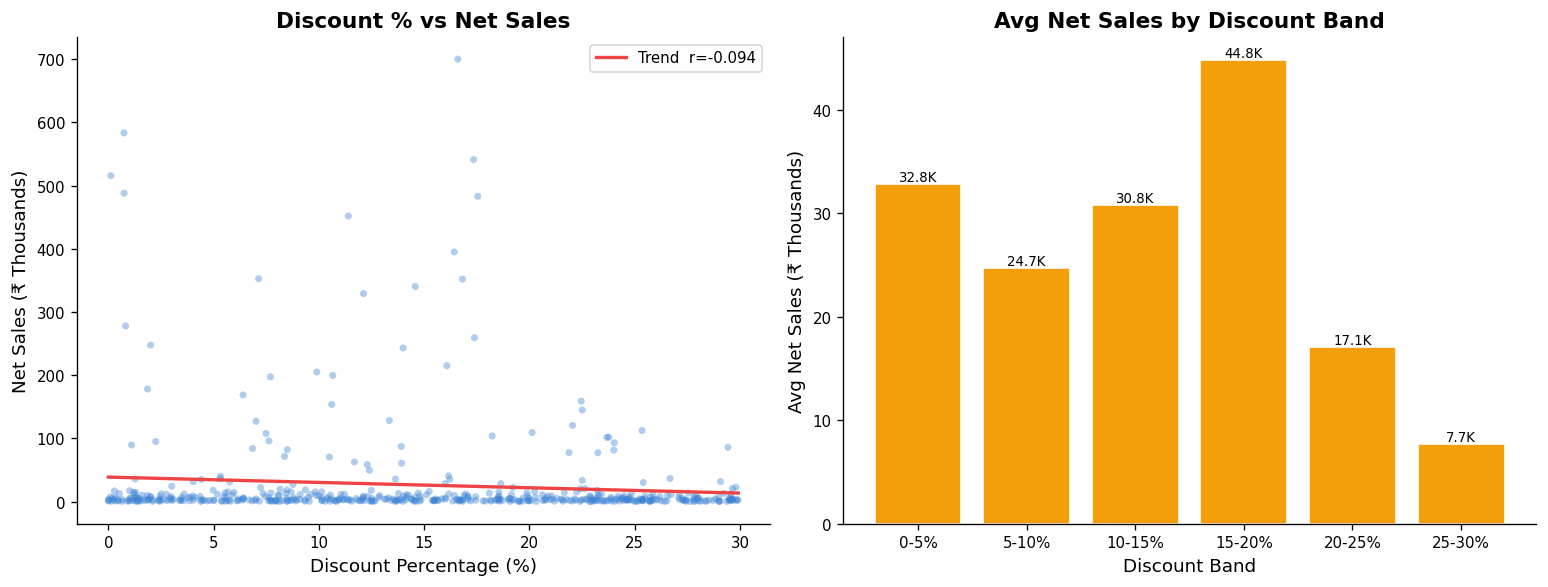

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Scatter plot
ax1.scatter(df['Discount_Percentage'], df['Net_Sales'] / 1e3,
            alpha=0.4, color=BLUE, s=18, edgecolors='none')

# Regression line
m, b = np.polyfit(df['Discount_Percentage'], df['Net_Sales'] / 1e3, 1)
x_line = np.linspace(df['Discount_Percentage'].min(),
                     df['Discount_Percentage'].max(), 100)
ax1.plot(x_line, m * x_line + b, color=RED, linewidth=2,
         label=f'Trend  r={corr:.3f}')
ax1.set_title('Discount % vs Net Sales', fontweight='bold')
ax1.set_xlabel('Discount Percentage (%)')
ax1.set_ylabel('Net Sales (₹ Thousands)')
ax1.legend(fontsize=9)

# Average Net Sales by discount band
ax2.bar(disc_band['Discount_Band'],
        disc_band['Avg_Net_Sales'] / 1e3,
        color=ORANGE, edgecolor='white')
for patch, val in zip(ax2.patches, disc_band['Avg_Net_Sales'] / 1e3):
    ax2.text(patch.get_x() + patch.get_width()/2, patch.get_height() + 0.3,
             f'{val:.1f}K', ha='center', fontsize=8)
ax2.set_title('Avg Net Sales by Discount Band', fontweight='bold')
ax2.set_xlabel('Discount Band')
ax2.set_ylabel('Avg Net Sales (₹ Thousands)')

plt.tight_layout()
plt.savefig('../reports/10_discount_vs_net_sales.png', bbox_inches='tight')
plt.show()

**Interpretation:**  
The Pearson correlation between `Discount_Percentage` and `Net_Sales` is **r = −0.094**, indicating a **very weak negative relationship**.  
This means discount levels do not meaningfully predict net sales in this dataset — order value is driven primarily by the product type (especially Electronics), not by discount size.  
The average net sales across all six discount bands are broadly similar, confirming the absence of a strong discount effect.

---
## Summary Table — All Key Results

| Analysis | Top Result | Value |
|---|---|---|
| Total Net Sales | Full year 2024 | ₹1,31,71,997 |
| Total Quantity Sold | — | 2,746 units |
| Transactions | — | 500 |
| Avg Order Value | — | ₹26,344 |
| Best Month | January 2024 | ₹18.87 L |
| Weakest Month | August 2024 | ₹5.12 L |
| Top City | Delhi | ₹20.0 L |
| Top Category | Electronics | ₹109.95 L (83.5%) |
| Top Product | Laptop | ₹56.9 L |
| Gender Split | Female / Male | 50.4% / 49.6% |
| Top Payment Method | Wallet | ₹31.8 L (24.2%) |
| Top Customer | Vivaan Shah | ₹7.0 L |
| Discount-Sales Correlation | Very weak negative | r = −0.094 |